In [1]:
import numpy as np
import sys
from matplotlib import pyplot as plot, cm
from mpl_toolkits.mplot3d import Axes3D #New library required for projected 3d plots

domain = 2
nx = ny = 81

x = np.linspace(0, domain, nx)
y = np.linspace(0, domain, ny)

dx = domain / (nx - 1)
dy = domain / (ny - 1)

# recall that i = domain / dx

u = np.ones((nx, ny))
u[int(0.5/dx):int((1/dx)+1), int(0.5/dy):int((1/dy)+1)] = 2

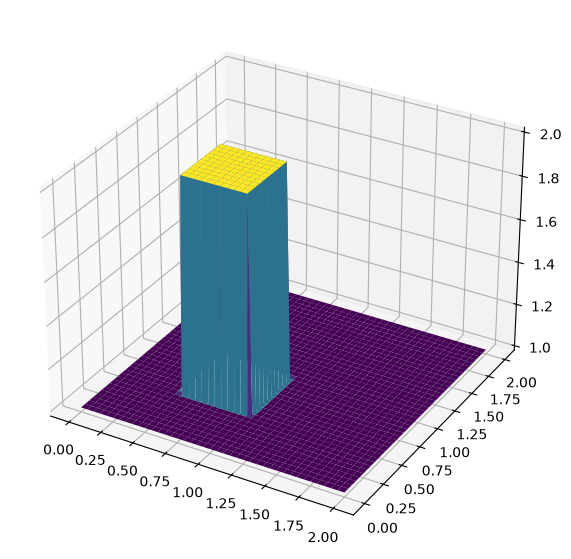

In [2]:
#plot initical condition
fig = plot.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.
X, Y = np.meshgrid(x, y)
surf = ax.plot_surface(X, Y, u, cmap=cm.viridis)

In [3]:
# discretization

c = 1
sigma = 0.2 # where sigma = dt/dx
dt = sigma * dx
nt = 100


for n in range(nt):
    un = u.copy()
    u[1:,1:] = (un[1:,1:] - (c * dt/dx) * (un[1:,1:] - un[:-1,1:])
              - (c * dt/dy) * (un[1:,1:] - un[1:,:-1]))
    
    # Boundary Conditions where u = 1
    # at lines whose equations are (x = 0, x = 2, y = 0, y = 0)
    u[0,:] = 1
    u[-1,:] = 1
    u[:,0] = 1
    u[:,-1] = 1

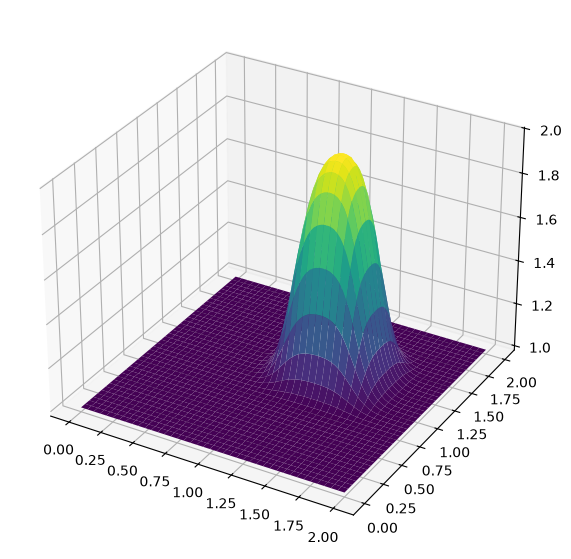

In [4]:
fig = plot.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.
X, Y = np.meshgrid(x,y)
surf = ax.plot_surface(X,Y,u,cmap=cm.viridis)